Mini Project for Big Data Analytics using pyspark

Topic: Employee Data Analysis

In [4]:
import findspark
findspark.init()

In [5]:
import pyspark

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, desc, round

In [7]:
# 1. Create Spark Session
spark = SparkSession.builder.appName("Employee Data Analysis").getOrCreate()

In [8]:
# 2. Load the dataset
df = spark.read.csv(r"C:\Users\Hp\Desktop\Employee_Data_Analysis\Employee_dataset.csv", header=True, inferSchema=True)

df.show(5)
df.printSchema()

+---+------------------+---+------+----------+------+------------+-----------------+----------+--------+-----------+-------+
| ID|              Name|Age|Gender|Department|Salary|Joining Date|Performance Score|Experience|  Status|   Location|Session|
+---+------------------+---+------+----------+------+------------+-----------------+----------+--------+-----------+-------+
|  1|      Cory Escobar| 48|Female|        HR|  5641|  2015-05-03|              2.0|        16|  Active|   New York|  Night|
|  2|   Timothy Sanchez| 25| Other|     Sales|  4249|  2020-11-09|              2.0|        11|Inactive|Los Angeles|Evening|
|  3|      Chad Nichols| 57| Other|     Sales|  3058|  2019-02-12|             NULL|         1|Inactive|   New York|Morning|
|  4|Christine Williams| 58|Female|        IT|  5895|  2017-09-08|              2.0|        13|Inactive|Los Angeles|Evening|
|  5|      Amber Harris| 35| Other|        IT|  4317|  2020-02-15|              5.0|        16|Inactive|   New York|Evening|


In [9]:
# 3. Data Cleaning
df_clean = df.dropna(subset=["Department", "Salary", "Experience"])

df_clean = df_clean.withColumn("Salary", col("Salary").cast("double"))
df_clean = df_clean.withColumn("Experience", col("Experience").cast("int"))

print("Cleaned Dataset:")
df_clean.show(5)

Cleaned Dataset:
+---+------------------+---+------+----------+------+------------+-----------------+----------+--------+-----------+-------+
| ID|              Name|Age|Gender|Department|Salary|Joining Date|Performance Score|Experience|  Status|   Location|Session|
+---+------------------+---+------+----------+------+------------+-----------------+----------+--------+-----------+-------+
|  1|      Cory Escobar| 48|Female|        HR|5641.0|  2015-05-03|              2.0|        16|  Active|   New York|  Night|
|  2|   Timothy Sanchez| 25| Other|     Sales|4249.0|  2020-11-09|              2.0|        11|Inactive|Los Angeles|Evening|
|  3|      Chad Nichols| 57| Other|     Sales|3058.0|  2019-02-12|             NULL|         1|Inactive|   New York|Morning|
|  4|Christine Williams| 58|Female|        IT|5895.0|  2017-09-08|              2.0|        13|Inactive|Los Angeles|Evening|
|  5|      Amber Harris| 35| Other|        IT|4317.0|  2020-02-15|              5.0|        16|Inactive|   N

In [10]:
# 4. Average Salary per Department
average_salary_department = df_clean.groupBy("Department").agg(
    round(avg("Salary"), 2).alias("Average Salary")
).orderBy(desc("Average Salary"))

print("Average Salary per Department:")
average_salary_department.show(truncate=False)

Average Salary per Department:
+----------+--------------+
|Department|Average Salary|
+----------+--------------+
|HR        |5982.4        |
|IT        |5968.37       |
|Sales     |5804.09       |
+----------+--------------+



In [11]:
# 5. Filter High Salary Employees
salary_threshold = 8000

high_salary_employees = df_clean.filter(col("Salary") > salary_threshold).select(
    "ID",
    "Name",
    "Department",
    "Salary",
    "Experience",
    "Status",
    "Location"
).orderBy(desc("Salary"))

print("High Salary Employees:")
high_salary_employees.show(10, truncate=False)

High Salary Employees:
+---+------------------+----------+------+----------+--------+-----------+
|ID |Name              |Department|Salary|Experience|Status  |Location   |
+---+------------------+----------+------+----------+--------+-----------+
|812|Jesse Miller      |HR        |9993.0|12        |Active  |Chicago    |
|532|Jeffrey Williamson|IT        |9988.0|16        |Inactive|Chicago    |
|990|Shannon Meyer     |HR        |9985.0|18        |Active  |Chicago    |
|128|Ashley Williams   |HR        |9973.0|19        |Inactive|New York   |
|938|Gary Mitchell     |Sales     |9963.0|20        |Inactive|Los Angeles|
|909|Sara Martinez     |HR        |9951.0|6         |Inactive|New York   |
|458|Emma Pratt        |IT        |9946.0|17        |Inactive|Los Angeles|
|121|David Hampton     |HR        |9941.0|15        |Inactive|New York   |
|201|Mr. James Johnson |HR        |9930.0|19        |Active  |Chicago    |
|797|Jacob Shannon     |Sales     |9926.0|7         |Active  |Chicago    |
+-

In [12]:
# 6. Sort Employees by Experience
employees_by_experience = df_clean.select(
    "ID",
    "Name",
    "Department",
    "Salary",
    "Experience",
    "Performance Score",
    "Status"
).orderBy(desc("Experience"), desc("Salary"))

print("Employees Sorted by Experience:")
employees_by_experience.show(10, truncate=False)

Employees Sorted by Experience:
+---+------------------+----------+------+----------+-----------------+--------+
|ID |Name              |Department|Salary|Experience|Performance Score|Status  |
+---+------------------+----------+------+----------+-----------------+--------+
|938|Gary Mitchell     |Sales     |9963.0|20        |5.0              |Inactive|
|251|Joshua Bullock    |Sales     |9924.0|20        |4.0              |Inactive|
|544|Erin Cunningham   |HR        |9838.0|20        |5.0              |Active  |
|567|Adam Thomas       |HR        |9370.0|20        |4.0              |Inactive|
|613|Kelsey Hines      |IT        |9282.0|20        |NULL             |Active  |
|809|Matthew Bonilla   |IT        |9092.0|20        |2.0              |Active  |
|844|Robert Goodman    |IT        |9051.0|20        |5.0              |Inactive|
|624|Anthony Miller    |Sales     |8635.0|20        |NULL             |Inactive|
|547|Louis Larsen      |Sales     |8608.0|20        |NULL             |Inacti

Visualization

Bar Chart: Average Salary per Department

In [1]:
import matplotlib.pyplot as plt

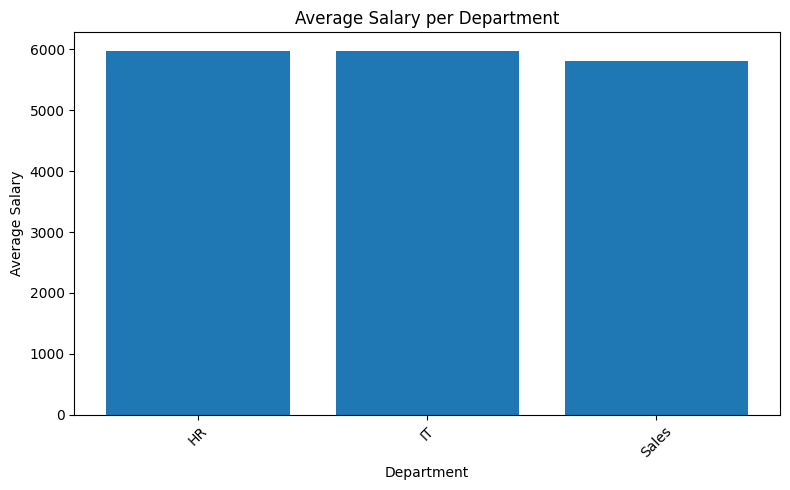

In [13]:
# PySpark aggregation
avg_salary_viz = df_clean.groupBy("Department").agg(
    round(avg("Salary"), 2).alias("Average Salary")
).orderBy(desc("Average Salary"))

# Collect small result for plotting
avg_salary_data = avg_salary_viz.collect()

departments = [row["Department"] for row in avg_salary_data]
average_salaries = [row["Average Salary"] for row in avg_salary_data]

plt.figure(figsize=(8, 5))
plt.bar(departments, average_salaries)
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.title("Average Salary per Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bar Chart: Number of Employees per Department

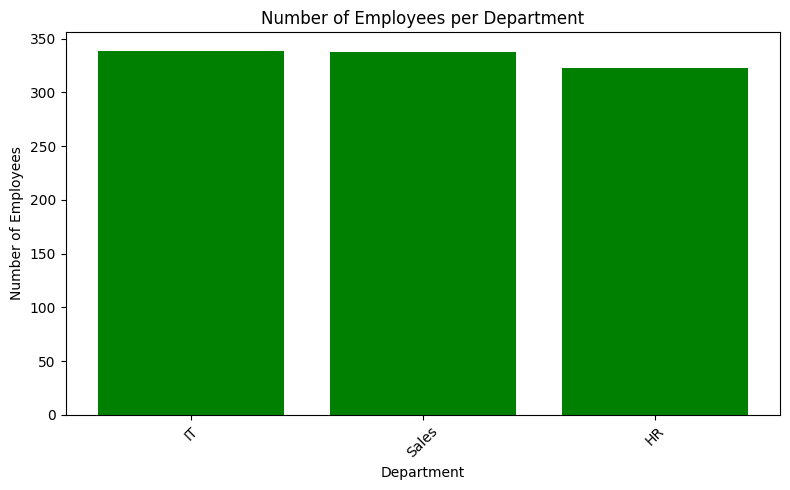

In [16]:
from pyspark.sql.functions import count
employee_count_viz = df_clean.groupBy("Department").agg(
    count("ID").alias("Number of Employees")
).orderBy(desc("Number of Employees"))

employee_count_data = employee_count_viz.collect()

departments = [row["Department"] for row in employee_count_data]
employee_counts = [row["Number of Employees"] for row in employee_count_data]

plt.figure(figsize=(8, 5))
plt.bar(departments, employee_counts, color="green")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.title("Number of Employees per Department")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pie Chart: High Salary Employees per Department

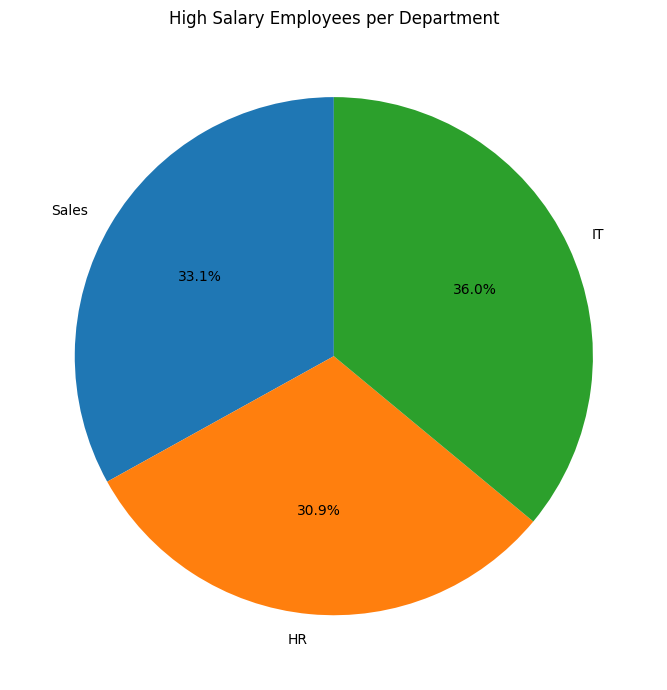

In [17]:
high_salary_viz = df_clean.filter(col("Salary") > 8000).groupBy("Department").agg(
    count("ID").alias("High Salary Employees")
)

high_salary_data = high_salary_viz.collect()

departments = [row["Department"] for row in high_salary_data]
high_salary_counts = [row["High Salary Employees"] for row in high_salary_data]

plt.figure(figsize=(7, 7))
plt.pie(high_salary_counts, labels=departments, autopct="%1.1f%%", startangle=90)
plt.title("High Salary Employees per Department")
plt.tight_layout()
plt.show()

Dot Chart: Top 10 Experienced Employees

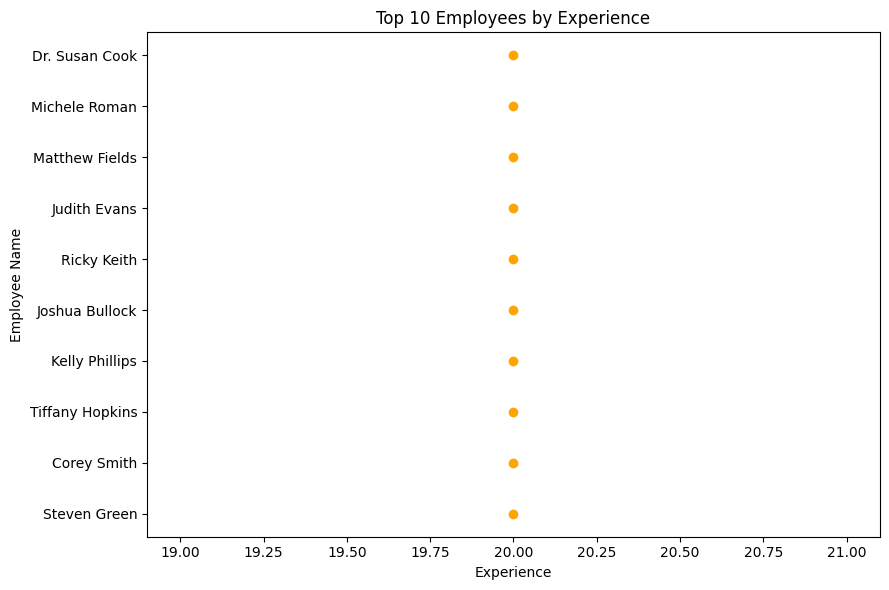

In [ ]:
top_experience_viz = df_clean.select(
    "Name", "Experience"
).orderBy(col("Experience").desc()).limit(10)

top_experience_data = top_experience_viz.collect()

names = [row["Name"] for row in top_experience_data]
experiences = [row["Experience"] for row in top_experience_data]

plt.figure(figsize=(9, 6))
plt.scatter(experiences, names, color="orange")
plt.xlabel("Experience")
plt.ylabel("Employee Name")
plt.title("Top 10 Employees by Experience")
plt.tight_layout()
plt.show()